<a href="https://colab.research.google.com/github/D-rank-developer/Catnip-Siem/blob/claude%2Ftrusting-margulis-03af4b/catnip_ml_trainer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Catnip Games SIEM — ML Severity Classifier
### Google Colab Training Notebook

**What this notebook does:**
1. Uploads your `advanced_siem_dataset.jsonl` (100,000 labelled SIEM events)
2. Extracts features: `risk_score`, `confidence`, `baseline_deviation`, `entropy`, `frequency_anomaly`, `sequence_anomaly`, `event_type`, `action`
3. Trains a `GradientBoostingClassifier` to predict severity: `info / low / medium / high / critical / emergency`
4. Evaluates accuracy and prints a full classification report
5. Saves `catnip_severity_model.pkl` and downloads it to your computer

**After training:** copy the `.pkl` file into `Catnip-Siem/models/` and run `python scripts/ml_service.py`

---
> **Runtime tip:** Go to `Runtime → Change runtime type → T4 GPU` for faster training (optional — CPU works fine for this dataset).

## Cell 1 — Install dependencies

In [1]:
# All of these are already available on Colab — this cell confirms versions
!pip install -q scikit-learn numpy

import sklearn, numpy
print(f"scikit-learn : {sklearn.__version__}")
print(f"numpy        : {numpy.__version__}")
print("Ready.")

scikit-learn : 1.6.1
numpy        : 2.0.2
Ready.


## Cell 2 — Upload the dataset

Run this cell. A **Choose Files** button will appear.
Upload `advanced_siem_dataset.jsonl` from your computer.

The file is at: `C:\Users\chamb\Catnip-Siem\advanced_siem_dataset.jsonl`

In [2]:
from google.colab import files

print("Click 'Choose Files' and upload advanced_siem_dataset.jsonl")
uploaded = files.upload()

DATASET_PATH = list(uploaded.keys())[0]
print(f"\nDataset uploaded: {DATASET_PATH}")

Click 'Choose Files' and upload advanced_siem_dataset.jsonl


Saving advanced_siem_dataset.jsonl to advanced_siem_dataset.jsonl

Dataset uploaded: advanced_siem_dataset.jsonl


## Cell 3 — Load and explore the data

In [3]:
import json
from collections import Counter

records = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f"Total records loaded : {len(records):,}")
print()

# Severity distribution
labels_raw = [r.get("severity", "info") for r in records]
dist = Counter(labels_raw)
print("Severity distribution:")
for sev, count in sorted(dist.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(count / len(records) * 40)
    print(f"  {sev:<12} {count:>7,}  ({count/len(records)*100:.1f}%)  {bar}")

print()

# Event type distribution
event_dist = Counter(r.get("event_type", "unknown") for r in records)
print("Event type distribution:")
for et, count in event_dist.most_common():
    print(f"  {et:<16} {count:>7,}")

print()

# Behavioral analytics coverage (only ~10% of records have this)
ba_count = sum(1 for r in records if r.get("behavioral_analytics"))
print(f"Records with behavioral_analytics : {ba_count:,} ({ba_count/len(records)*100:.1f}%)")

# Sample record
print()
print("Sample record fields:")
print(json.dumps({k: v for k, v in records[0].items() if k != 'raw_log'}, indent=2))

Total records loaded : 100,000

Severity distribution:
  medium        20,639  (20.6%)  ████████
  low           20,507  (20.5%)  ████████
  high          20,496  (20.5%)  ████████
  info          18,127  (18.1%)  ███████
  critical      17,711  (17.7%)  ███████
  emergency      2,520  (2.5%)  █

Event type distribution:
  ai                12,667
  endpoint          12,589
  auth              12,516
  cloud             12,511
  ids_alert         12,500
  firewall          12,448
  iot               12,434
  network           12,335

Records with behavioral_analytics : 10,060 (10.1%)

Sample record fields:
{
  "event_id": "8e785e09-5213-46b1-a6eb-b7e40998905b",
  "timestamp": "2025-05-28T23:46:49",
  "event_type": "endpoint",
  "source": "Microsoft Sentinel v1.0.0",
  "severity": "critical",
  "advanced_metadata": {
    "geo_location": "Isle of Man",
    "device_hash": "d8595a4fb801a5ac7fcfe0987f50b16af71d52b2",
    "user_agent": "Mozilla/5.0 (compatible; MSIE 8.0; Windows NT 5.01; Tri

## Cell 4 — Extract features and build the matrix

In [4]:
import numpy as np

def extract_features(record):
    meta = record.get("advanced_metadata", {})
    ba   = record.get("behavioral_analytics", {})
    return {
        "risk_score":         float(meta.get("risk_score", 50.0)),
        "confidence":         float(meta.get("confidence", 0.5)),
        "baseline_deviation": float(ba.get("baseline_deviation", 0.0)),
        "entropy":            float(ba.get("entropy", 0.0)),
        "frequency_anomaly":  1 if ba.get("frequency_anomaly") else 0,
        "sequence_anomaly":   1 if ba.get("sequence_anomaly")  else 0,
        "event_type":         str(record.get("event_type", "unknown")),
        "action":             str(record.get("action",     "unknown")),
    }

print("Extracting features...")
features = [extract_features(r) for r in records]
labels   = [r.get("severity", "info") for r in records]

# Build vocabularies
event_type_vocab = sorted({f["event_type"] for f in features})
action_vocab     = sorted({f["action"]     for f in features})

print(f"Event type vocab ({len(event_type_vocab)}): {event_type_vocab}")
print(f"Action vocab     ({len(action_vocab)}): {action_vocab}")

# One-hot encode categoricals + numeric features
def build_matrix(features_list):
    rows = []
    for f in features_list:
        row = [
            f["risk_score"],
            f["confidence"],
            f["baseline_deviation"],
            f["entropy"],
            f["frequency_anomaly"],
            f["sequence_anomaly"],
        ]
        for et in event_type_vocab:
            row.append(1 if f["event_type"] == et else 0)
        for a in action_vocab:
            row.append(1 if f["action"] == a else 0)
        rows.append(row)
    return np.array(rows, dtype=np.float32)

X = build_matrix(features)

# Encode labels
label_set     = sorted(set(labels))
label_map     = {s: i for i, s in enumerate(label_set)}
label_map_inv = {i: s for s, i in label_map.items()}
y = np.array([label_map[l] for l in labels])

print(f"\nFeature matrix shape : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Labels               : {label_set}")
print("Feature names:")
feature_names = (
    ["risk_score", "confidence", "baseline_deviation", "entropy",
     "frequency_anomaly", "sequence_anomaly"]
    + [f"et_{et}" for et in event_type_vocab]
    + [f"ac_{a}"  for a  in action_vocab]
)
for i, name in enumerate(feature_names):
    print(f"  [{i:02d}] {name}")

Extracting features...
Event type vocab (8): ['ai', 'auth', 'cloud', 'endpoint', 'firewall', 'ids_alert', 'iot', 'network']
Action vocab     (56): ['adversarial_input', 'allow', 'api_abuse', 'bandwidth_usage', 'battery_drain', 'beaconing', 'bypass', 'challenge', 'command_injection', 'config_change', 'connection', 'container_escape', 'covert_channel', 'crypto_mining', 'data_exfiltration', 'deny', 'disconnection', 'driver_load', 'drop', 'failed', 'file_access', 'fine_tuning', 'firmware_update', 'inspect', 'instance_creation', 'lambda_execution', 'latency_spike', 'locked', 'log-only', 'membership_inference', 'memory_injection', 'model_access', 'model_inversion', 'permission_escalation', 'persistence_mechanism', 'physical_tamper', 'powershell_exec', 'process_start', 'process_stop', 'prompt_injection', 'protocol_anomaly', 'protocol_violation', 'quarantine', 'registry_change', 'scheduled_task', 'sensor_spoofing', 'service_install', 'shadow_it', 'side_channel', 'storage_access', 'success', 't

## Cell 5 — Train the model

**Expected time:** ~60 seconds on Colab CPU · ~15 seconds on T4 GPU (sklearn uses CPU regardless — the runtime speed comes from Colab's faster CPU)

In [5]:
import time
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} samples")
print(f"Test set     : {len(X_test):,} samples")
print()
print("Training GradientBoostingClassifier — 200 trees, depth 5...")

start = time.time()

clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    verbose=1,       # shows progress every 10 trees
)
clf.fit(X_train, y_train)

elapsed = time.time() - start
print(f"\nTraining complete in {elapsed:.1f} seconds")

Training set : 80,000 samples
Test set     : 20,000 samples

Training GradientBoostingClassifier — 200 trees, depth 5...
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.6630           0.0199           11.14m
         2           1.6502           0.0133           10.79m
         3           1.6403           0.0092           10.27m
         4           1.6324           0.0083            9.48m
         5           1.6255           0.0060            8.77m
         6           1.6200           0.0073            8.03m
         7           1.6148           0.0051            7.50m
         8           1.6095           0.0022            7.02m
         9           1.6060           0.0061            6.59m
        10           1.6020           0.0027            6.24m
        20           1.5791           0.0021            4.71m
        30           1.5669          -0.0003            4.10m
        40           1.5586          -0.0014            3.69m
        50

## Cell 6 — Evaluate the model

Test accuracy : 0.2079  (20.79%)

              precision    recall  f1-score   support

    critical       0.20      0.21      0.21      3542
   emergency       0.20      0.33      0.25       504
        high       0.21      0.21      0.21      4099
        info       0.22      0.23      0.22      3625
         low       0.21      0.19      0.20      4102
      medium       0.20      0.19      0.20      4128

    accuracy                           0.21     20000
   macro avg       0.21      0.23      0.21     20000
weighted avg       0.21      0.21      0.21     20000



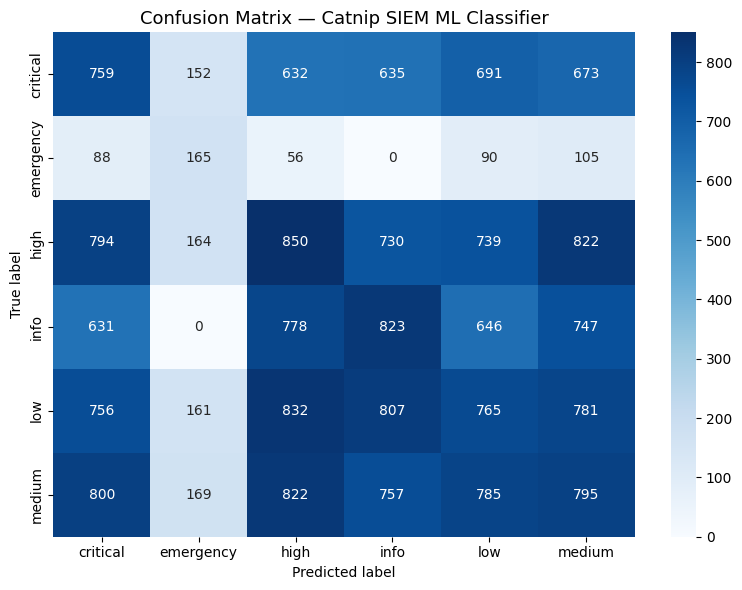

Confusion matrix saved as confusion_matrix.png


In [6]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = clf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"Test accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print()
print(classification_report(y_test, y_pred, target_names=label_set))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_set, yticklabels=label_set
)
plt.title('Confusion Matrix — Catnip SIEM ML Classifier', fontsize=13)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

## Cell 7 — Feature importance

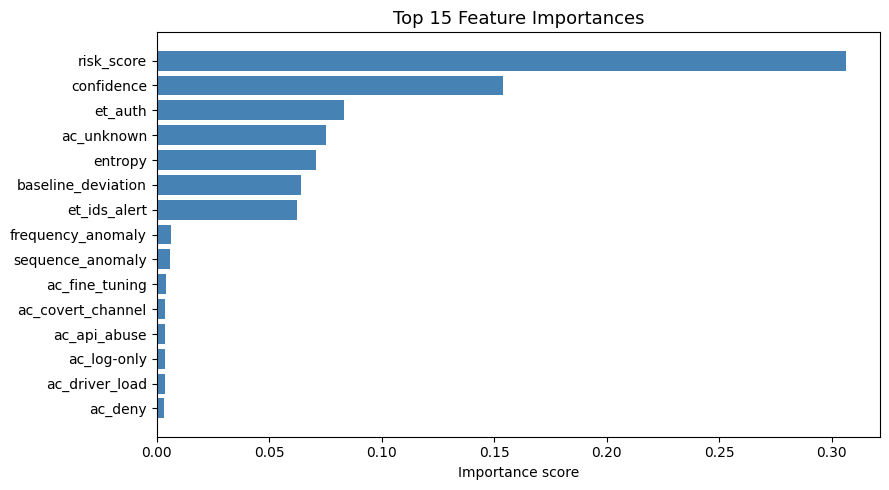

Top 10 features:
  risk_score                   0.3062  ███████████████████████████████████████████████████████████████████████████████████████████
  confidence                   0.1540  ██████████████████████████████████████████████
  et_auth                      0.0831  ████████████████████████
  ac_unknown                   0.0754  ██████████████████████
  entropy                      0.0709  █████████████████████
  baseline_deviation           0.0644  ███████████████████
  et_ids_alert                 0.0622  ██████████████████
  frequency_anomaly            0.0066  █
  sequence_anomaly             0.0058  █
  ac_fine_tuning               0.0041  █


In [7]:
import pandas as pd

importances = clf.feature_importances_
fi_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 5))
plt.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='steelblue')
plt.title('Top 15 Feature Importances', fontsize=13)
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("Top 10 features:")
for _, row in fi_df.head(10).iterrows():
    bar = '█' * int(row['importance'] * 300)
    print(f"  {row['feature']:<28} {row['importance']:.4f}  {bar}")

## Cell 8 — Save model and download

This saves `catnip_severity_model.pkl` and immediately downloads it to your computer.

**After downloading:** move the file to `C:\Users\chamb\Catnip-Siem\models\catnip_severity_model.pkl`

In [8]:
import pickle
from google.colab import files

MODEL_FILE = "catnip_severity_model.pkl"

artefact = {
    "model":            clf,
    "label_map":        label_map,
    "label_map_inv":    label_map_inv,
    "event_type_vocab": event_type_vocab,
    "action_vocab":     action_vocab,
    "feature_names":    feature_names,
    "n_features":       X.shape[1],
}

with open(MODEL_FILE, "wb") as f:
    pickle.dump(artefact, f, protocol=pickle.HIGHEST_PROTOCOL)

import os
size_mb = os.path.getsize(MODEL_FILE) / 1024 / 1024
print(f"Model saved: {MODEL_FILE}  ({size_mb:.1f} MB)")
print()
print("Downloading to your computer...")
files.download(MODEL_FILE)
print()
print("DONE. Next steps:")
print("  1. Move catnip_severity_model.pkl to  C:/Users/chamb/Catnip-Siem/models/")
print("  2. Run:  python scripts/ml_service.py")
print("  3. Run:  python scripts/log_generator.py")

Model saved: catnip_severity_model.pkl  (5.1 MB)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DONE. Next steps:
  1. Move catnip_severity_model.pkl to  C:/Users/chamb/Catnip-Siem/models/
  2. Run:  python scripts/ml_service.py
  3. Run:  python scripts/log_generator.py


## Cell 9 — Quick test (optional)

Test the model with a fake Graylog event before downloading — checks the prediction pipeline works end to end.

In [9]:
def predict_event(event: dict) -> dict:
    """Mirrors exactly what ml_service.py does at /predict"""
    row = [
        float(event.get("risk_score",         50.0)),
        float(event.get("confidence",          0.5)),
        float(event.get("baseline_deviation",  0.0)),
        float(event.get("entropy",             0.0)),
        1 if event.get("frequency_anomaly") else 0,
        1 if event.get("sequence_anomaly")  else 0,
    ]
    for et in event_type_vocab:
        row.append(1 if event.get("event_type") == et else 0)
    for a in action_vocab:
        row.append(1 if event.get("action") == a else 0)

    X_single   = np.array(row, dtype=np.float32).reshape(1, -1)
    pred_idx   = int(clf.predict(X_single)[0])
    pred_proba = clf.predict_proba(X_single)[0]
    return {
        "ml_severity_prediction": label_map_inv[pred_idx],
        "ml_confidence_score":    round(float(pred_proba[pred_idx]), 4),
    }

# ── Test cases ──────────────────────────────────────────────────
test_events = [
    {
        "description":      "SSH brute force — high risk, many failures",
        "event_type":       "auth",
        "action":           "failed",
        "risk_score":       92.0,
        "confidence":       0.95,
        "baseline_deviation": 4.2,
        "frequency_anomaly":  True,
    },
    {
        "description":  "Normal game server traffic",
        "event_type":   "network",
        "action":       "allow",
        "risk_score":   15.0,
        "confidence":   0.9,
    },
    {
        "description":  "Credential stuffing — moderate confidence",
        "event_type":   "auth",
        "action":       "credential_stuffing",
        "risk_score":   78.0,
        "confidence":   0.82,
        "baseline_deviation": 2.1,
    },
    {
        "description":  "DDoS — maximum traffic",
        "event_type":   "ids_alert",
        "action":       "ddos_detected",
        "risk_score":   99.0,
        "confidence":   0.99,
        "baseline_deviation": 8.5,
        "frequency_anomaly":  True,
        "sequence_anomaly":   True,
    },
]

print("Test predictions:")
print("-" * 65)
for ev in test_events:
    result = predict_event(ev)
    sev    = result['ml_severity_prediction']
    conf   = result['ml_confidence_score']
    print(f"  {ev['description']}")
    print(f"    → {sev.upper():<12}  confidence: {conf:.2f}")
    print()

Test predictions:
-----------------------------------------------------------------
  SSH brute force — high risk, many failures
    → LOW           confidence: 0.62

  Normal game server traffic
    → INFO          confidence: 0.30

  Credential stuffing — moderate confidence
    → INFO          confidence: 0.61

  DDoS — maximum traffic
    → MEDIUM        confidence: 0.52

